# Import


In [1]:
import numpy as np

import torch
import torch.nn as nn
import torch.nn.functional as F
# import torchvision
import torchvision.transforms as transforms


In [2]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device

device(type='cuda')

# Dataset

In [3]:
dataset_path = r'C:\Nicole\Master_NTUB_11366001\Datasets\Mixed-type Wafer Defect Datasets_Kaggle\Wafer_Map_Datasets.npz'
# f'' 是 f-string, 用於格式化字串 (插入變數). 
# r'' 是 raw string, 用於原始字串, 不會處理跳脫字元 (如 \n、\t）, 常用於正則表達式或 Windows 路徑.
dataset_raw = np.load(dataset_path)
dataset_raw

NpzFile 'C:\\Nicole\\Master_NTUB_11366001\\Datasets\\Mixed-type Wafer Defect Datasets_Kaggle\\Wafer_Map_Datasets.npz' with keys: arr_0, arr_1

## Glance

In [4]:
dataset_raw['arr_1'][0]
# label vector is type of defect(s): (Center, Donut, Edge_Loc, Edge_Ring, Loc, Near_Full, Scratch, Random)
# normal = (0, 0, 0, 0, 0, 0, 0, 0)
# Donut = (0, 1, 0, 0, 0, 0, 0, 0)
# Donut + Scratch = (0, 1, 0, 0, 0, 0, 1, 0)

array([1, 0, 1, 0, 0, 0, 1, 0])

In [5]:
# 各個故障型別的次數
defect_types, counts = np.unique(dataset_raw['arr_1'], return_counts=True, axis=0)
# print(f'types count: {len(values)}')
# for i in range(len(values)):
#     print((values[i], counts[i]))

# # types count: 38
# # (array([0, 0, 0, 0, 0, 0, 0, 0]), 1000)
# # (array([0, 0, 0, 0, 0, 0, 0, 1]), 866)  # Radom
# # (array([0, 0, 0, 0, 0, 0, 1, 0]), 1000)
# # (array([0, 0, 0, 0, 0, 1, 0, 0]), 149)  # Near_Full
# # (array([0, 0, 0, 0, 1, 0, 0, 0]), 1000)
# # (array([0, 0, 0, 0, 1, 0, 1, 0]), 1000)
# # (array([0, 0, 0, 1, 0, 0, 0, 0]), 1000)
# # (array([0, 0, 0, 1, 0, 0, 1, 0]), 1000)
# # (array([0, 0, 0, 1, 1, 0, 0, 0]), 1000)
# # (array([0, 0, 0, 1, 1, 0, 1, 0]), 1000)
# # (array([0, 0, 1, 0, 0, 0, 0, 0]), 1000)
# # (array([0, 0, 1, 0, 0, 0, 1, 0]), 1000)
# # (array([0, 0, 1, 0, 1, 0, 0, 0]), 1000)
# # (array([0, 0, 1, 0, 1, 0, 1, 0]), 1000)
# # (array([0, 1, 0, 0, 0, 0, 0, 0]), 1000)
# # (array([0, 1, 0, 0, 0, 0, 1, 0]), 1000)
# # (array([0, 1, 0, 0, 1, 0, 0, 0]), 1000)
# # (array([0, 1, 0, 0, 1, 0, 1, 0]), 1000)
# # (array([0, 1, 0, 1, 0, 0, 0, 0]), 1000)
# # (array([0, 1, 0, 1, 0, 0, 1, 0]), 1000)
# # (array([0, 1, 0, 1, 1, 0, 0, 0]), 1000)
# # (array([0, 1, 0, 1, 1, 0, 1, 0]), 1000)
# # (array([0, 1, 1, 0, 0, 0, 0, 0]), 1000)
# # (array([0, 1, 1, 0, 0, 0, 1, 0]), 1000)
# # (array([0, 1, 1, 0, 1, 0, 0, 0]), 1000)
# # (array([0, 1, 1, 0, 1, 0, 1, 0]), 1000)
# # (array([1, 0, 0, 0, 0, 0, 0, 0]), 1000)
# # (array([1, 0, 0, 0, 0, 0, 1, 0]), 1000)
# # (array([1, 0, 0, 0, 1, 0, 0, 0]), 1000)
# # (array([1, 0, 0, 0, 1, 0, 1, 0]), 1000)
# # (array([1, 0, 0, 1, 0, 0, 0, 0]), 1000)
# # (array([1, 0, 0, 1, 0, 0, 1, 0]), 1000)
# # (array([1, 0, 0, 1, 1, 0, 0, 0]), 1000)
# # (array([1, 0, 0, 1, 1, 0, 1, 0]), 1000)
# # (array([1, 0, 1, 0, 0, 0, 0, 0]), 1000)
# # (array([1, 0, 1, 0, 0, 0, 1, 0]), 2000)
# # (array([1, 0, 1, 0, 1, 0, 0, 0]), 1000)
# # (array([1, 0, 1, 0, 1, 0, 1, 0]), 1000)


In [6]:
# # 畫出指定缺陷類型的晶圓圖
# import matplotlib.pyplot as plt
# label = (0, 0, 0, 0, 0, 0, 0, 1)  # Random
# # label = (0, 0, 0, 0, 0, 1, 0, 0)  # Near_Full
# # label = (1, 0, 1, 0, 0, 0, 1, 0)
# mask = (dataset_raw['arr_1'] == label).all(axis=1)
# wafermap = dataset_raw['arr_0'][mask][0]
# plt.imshow(wafermap)
# plt.suptitle(f'{label}', fontsize=18)
# plt.tight_layout()
# plt.axis('off')

## Splitting into train/test 

In [7]:
batch_size = 64
wafer_resize_scale = (64, 64)

class WafermapDataset(torch.utils.data.Dataset):
    def __init__(self, dataset_raw, transform=None):
        super(WafermapDataset, self).__init__()
        self.wafermap = dataset_raw['arr_0']
        self.label = dataset_raw['arr_1']
        self.transform = transform
    
    def __len__(self):
        return len(self.label)
    
    def __getitem__(self, index):
        wafermap = torch.tensor(self.wafermap[index], dtype=torch.float)
        if self.transform: wafermap = self.transform(wafermap)
        label = torch.tensor(self.label[index], dtype=torch.float)

        return (wafermap, label)


transform = transforms.Compose([
    transforms.ToPILImage(),  
    transforms.Resize(wafer_resize_scale), 
    transforms.ToTensor()
])


dataset = WafermapDataset(dataset_raw, transform=transform)
# dataloader = torch.utils.data.DataLoader(dataset, batch_size=batch_size)

In [8]:
from sklearn.model_selection import train_test_split
test_size = 0.2  # 20% for testing

train_indices, test_indices = train_test_split(np.arange(len(dataset)), test_size=test_size, random_state=42, stratify=dataset.label)
train_dataset = torch.utils.data.Subset(dataset, train_indices)
test_dataset = torch.utils.data.Subset(dataset, test_indices)

train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=batch_size)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=batch_size)

In [9]:
dataset.label.shape

(38015, 8)

In [10]:
# 計算 test_loader 中每個類別的數量
from collections import Counter
test_labels = [label.numpy() for _, label in test_loader]
test_labels_flat = [tuple(label) for sublist in test_labels for label in sublist]
label_counts = Counter(test_labels_flat)
len(label_counts)
label_counts

Counter({(1.0, 0.0, 1.0, 0.0, 0.0, 0.0, 1.0, 0.0): 400,
         (0.0, 0.0, 0.0, 1.0, 1.0, 0.0, 1.0, 0.0): 200,
         (1.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0): 200,
         (1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0): 200,
         (0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0): 200,
         (0.0, 0.0, 1.0, 0.0, 1.0, 0.0, 1.0, 0.0): 200,
         (0.0, 1.0, 0.0, 1.0, 1.0, 0.0, 0.0, 0.0): 200,
         (1.0, 0.0, 0.0, 1.0, 0.0, 0.0, 1.0, 0.0): 200,
         (0.0, 1.0, 0.0, 0.0, 1.0, 0.0, 1.0, 0.0): 200,
         (0.0, 1.0, 0.0, 1.0, 1.0, 0.0, 1.0, 0.0): 200,
         (0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0): 200,
         (1.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0): 200,
         (0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0): 200,
         (0.0, 1.0, 1.0, 0.0, 0.0, 0.0, 1.0, 0.0): 200,
         (1.0, 0.0, 0.0, 1.0, 1.0, 0.0, 0.0, 0.0): 200,
         (0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0): 200,
         (0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0): 200,
         (0.0, 0.0, 0.0, 1.0, 1.0, 0.0, 0.0, 0.0

In [11]:
# 建立一個只有單一缺陷晶圓圖的訓練集
# 用於嘗試 "讓 R 專注訓練辨識單一缺陷類型, 再訓練辨識複合缺陷類型", 看是否能提升模型的準確率

train_indices = []
for i, data in enumerate(train_dataset):
     if data[1].sum().item() <= 1: train_indices.append(i)
train_dataset_single_defect = torch.utils.data.Subset(train_dataset, train_indices)
train_loader_single_defect = torch.utils.data.DataLoader(train_dataset_single_defect, batch_size=batch_size)

# Generating Perfect WaferMap

In [12]:
def generate_perfect_wafermap(n_batch: int, size: tuple=wafer_resize_scale) -> torch.Tensor:
    """
    :param int n_batch: Number of wafer maps to generate.
    :param tuple size: Size of the wafer map (height, width).
    :return: A tensor of shape (n_batch, 1, height, width).
    """
    r = size[0] / 2
    rr = r ** 2
    wafermap_perfect = torch.zeros(size, dtype=torch.float).to(device)
    for x in range(size[0]):
        for y in range(size[1]):
            if (x - r + 0.5)**2 + (y - r + 0.5)**2 <= rr:
                wafermap_perfect[x][y] = 1
    wafermap_perfect = wafermap_perfect.expand(n_batch, 1, size[0], size[1])
    return wafermap_perfect.to(device)

    # label_perfect = torch.zeros((n_batch, 8), dtype=torch.float).to(device)  # Normal wafermap
    # return (wafermap_perfect.to(device), label_perfect.to(device))

# General Function

In [13]:
def rectify_pixel_values(x:torch.Tensor):
    """
    Make `x` pixel values in {0, 0.5, 1}.

    :param x: input tensor, shape=(B, C, H, W) or (C, H, W)
    :return: processed tensor, shape=(B, C, H, W) or (C, H, W)
    :raises TypeError: if `x` is not 3D or 4D
    """
    if x.dim() == 3:
        x = torch.round(x / x.max() * 2) / 2
        return torch.clamp(x, 0, 1)
    elif x.dim() == 4:
        new_tensor = []
        for item in x:
            new_tensor.append(rectify_pixel_values(item))
        return torch.stack(new_tensor)
    else:
        raise TypeError(f'函式只接受3維或4維的tensor. 輸入的tensor維度為{x.dim()} (shape={x.shape}). ')

In [14]:
import matplotlib.pyplot as plt
import time

def draw_loss_with_lr(model_name: str, log_loss: list, log_lr: list, epochs: int, model_config: str='(not provided)') -> plt.Figure:
    fig, ax1 = plt.subplots(figsize=(18, 4))

    # --- 左側 Y 軸：loss（線性尺度） ---
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Loss', color='tab:blue')
    ax1.plot(range(epochs), log_loss, label='Loss', color='tab:blue')
    ax1.tick_params(axis='y', labelcolor='tab:blue')

    # --- 右側 Y 軸：learning rate（對數尺度） ---
    ax2 = ax1.twinx()
    ax2.set_yscale('log')  # <<< 對數尺度
    ax2.set_ylabel('Learning Rate', color='tab:red')
    ax2.plot(range(epochs), log_lr, label='lr', color='tab:red', linestyle='--')
    ax2.tick_params(axis='y', labelcolor='tab:red')
    
    timestamp = time.strftime('%Y%m%d-%H%M%S', time.localtime())
    fig.text(0.95, 0.90, f'timestamp={timestamp}.', transform=fig.transFigure, ha='right', fontsize=10, color='gray')
    fig.text(0.06, 0.16, f'model config=\n{model_config}', transform=fig.transFigure, ha='left', va='bottom', fontsize=10, color='gray')
    fig.suptitle(f'{model_name}: Loss per Epoch')
    fig.legend()
    fig.tight_layout()

    return fig, timestamp

In [15]:
# draw confusion matrix to show accuracy of each defect class
from mpl_toolkits.axes_grid1 import make_axes_locatable 
import time
# axes_grid1 是 plt 的附屬套件.
# make_axes_locatable 用於精準控制多個子圖 (subplot) 或 colorbar 的位置與大小. 

def draw_confusion_matrix(fusion_matrix: np.ndarray, defect_types_name: list, title: str='Confusion Matrix of Each Defect Class') -> plt.Figure:
    fig, ax = plt.subplots(figsize=(20, 16))
    cax = ax.matshow(fusion_matrix, cmap='Blues')
    divider = make_axes_locatable(ax)   # 建立一個「分隔器」(divider), 讓使用者在 ax 所在的主繪圖區附近, 動態加入額外的座標軸 (Axes), 例如 colorbar 的座標軸. 
    cbar_ax = divider.append_axes("right", size="1%", pad=0.03)  # cbar_ax 是 colorbar 的位置. size: colorbar 的寬度, 越小越細.
    fig.colorbar(cax, cax=cbar_ax) # pad: colorbar 與主圖之間的距離. fraction: colorbar 高度相對於主繪圖區的比例 (數值越小越矮). 

    # Set ticks and labels
    ax.set_xticks(np.arange(len(defect_types_name)))
    ax.set_yticks(np.arange(len(defect_types_name)))
    ax.set_xticklabels(defect_types_name, rotation=45, ha='center', fontsize=10)
    ax.set_yticklabels(defect_types_name, fontsize=10)

    # Set axis labels
    ax.set_xlabel('Predicted Class')
    ax.set_ylabel('True Class')
    ax.set_title(title)

    # Annotate each cell with the percentage value
    for i in range(len(defect_types_name)):
        for j in range(len(defect_types_name)):
            # percentage = fusion_matrix[i, j] / fusion_matrix.sum(axis=1)[i] if fusion_matrix.sum(axis=1)[i] > 0 else 0
            # font_color = 'white' if (percentage > 0.5) else 'black' # acc 較高的時候, 底色比較深, 所以字的顏色要改為白色
            # ax.text(j, i, f'{percentage:.4f}'.lstrip('0'), ha='center', va='center', color=font_color, fontsize=8)
            # # ax.text(j, i, f'{fusion_matrix[i, j]} ({percentage:.1f})', ha='center', va='center', color='black', fontsize=7)

            font_color = 'white' if (fusion_matrix[i, j] > 0.5) else 'black' # acc 較高的時候, 底色比較深, 所以字的顏色要改為白色
            ax.text(j, i, f'{fusion_matrix[i, j]:.4f}'.lstrip('0'), ha='center', va='center', color=font_color, fontsize=8)

    # # Annotate each cell with the numeric value
    # for i in range(len(class_names)):
    #     for j in range(len(class_names)):
    #         ax.text(j, i, fusion_matrix[i, j], ha='center', va='center', color='black')

    timestamp = time.strftime('%Y%m%d-%H%M%S', time.localtime())
    fig.text(0.85, 0.98, f'timestamp={timestamp}.', transform=fig.transFigure, ha='right', fontsize=10, color='gray')
    plt.tight_layout()
    return fig, timestamp

# Data Augmentation


## Colorization VAE

* F: feature extractor
    * R: resnet
    * A: return (attenMap, wab)
        * stitching module
        * theta
        * phi
* C: colorizer

### F: feature processing network


#### R

##### func.: training

In [16]:
def train_R(model, train_loader, criterion, optimizer, scheduler=None, epochs=50):
    model.train()
    log_loss, log_lr = [], []

    for epoch in range(epochs):
        running_loss = 0
        for wafermap, label in train_loader:
            optimizer.zero_grad()
            wafermap = wafermap.to(device)
            label = label.type(torch.float).to(device)  # BCEWithLogitsLoss expects float labels

            predict, _ = model(wafermap)
            # predict = torch.sigmoid(predict) # 這行不需要, 因為 criterion 是 BCEWithLogitsLoss, 它會「內部」對 input 進行 Sigmoid 轉換.
            # ↑ 只有在 inference 時才需要加上 Sigmoid, 因為 inference 時不會使用 criterion, 所以需要手動將 logits 轉換為 probabilities.
            loss = criterion(predict, label)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()

        if scheduler: scheduler.step(running_loss)
        loss_avg = running_loss / len(train_loader)
        log_loss.append(loss_avg)
        log_lr.append(optimizer.param_groups[0]['lr'])
        if (epoch + 1) % 10 == 0: print(f'Epoch [{epoch+1:3d}/{epochs:3d}] loss: {loss_avg:.9f}, lr: {optimizer.param_groups[0]['lr']:.9f}')
            
    return log_loss, log_lr

##### func.: inference

In [17]:
defect_vector_means = ('Center', 'Donut', 'Edge_Loc', 'Edge_Ring', 'Loc', 'Near_Full', 'Scratch', 'Random')
defect_vector_means_short = ('C', 'D', 'EL', 'ER', 'L', 'NF', 'S', 'R')

labels_in_code = []
for vector in defect_types:
    label = ''
    if sum(vector) == 0:
        label = 'none'
    elif sum(vector) == 1:
        label = defect_vector_means[vector.argmax()]
    else:
        for i, d in enumerate(vector):
            if d == 1: label += defect_vector_means_short[i] + '+'
        label = label.rstrip('+')  # 去掉最後的 '+'
    labels_in_code.append(label)
labels_in_code.append('XXX')    # 若有其他類型的缺陷, 用 'XXX' 來表示


label_to_code = {tuple(k): labels_in_code[i] for i, k in enumerate(defect_types)}
# label_to_code
# {(0, 0, 0, 0, 0, 0, 0, 0): 'none',
#  (0, 0, 0, 0, 0, 0, 0, 1): 'Random',
#  (0, 0, 0, 0, 0, 0, 1, 0): 'Scratch',
#  (0, 0, 0, 0, 0, 1, 0, 0): 'Near_Full',
#  (0, 0, 0, 0, 1, 0, 0, 0): 'Loc',
#  (0, 0, 0, 0, 1, 0, 1, 0): 'L+S',
#  ...
#  (1, 0, 1, 0, 1, 0, 1, 0): 'C+EL+L+S'}

In [18]:
from sklearn.metrics import confusion_matrix
# import matplotlib.pyplot as plt
# import seaborn as sns

@torch.no_grad()
def inference_Rref(model, test_loader, defect_types):
    model.eval()
    all_preds = []
    all_labels = []

    for wafermap, label in test_loader:
        wafermap = wafermap.to(device)
        label = label.to(device)
        label_ = [label_to_code[tuple(x)] for x in label.cpu().numpy()] # 把 ground truth label 轉換成代碼, 用於計算 confusion matrix

        predict, _ = model(wafermap)    
        predict = torch.sigmoid(predict)  # R 的預測值 (predict) 沒有經過 activation function, 所以這邊才會做 torch.sigmoid. 
        predict = predict.cpu().numpy() > 0.5   # Convert logits to binary predictions
        # ↑ predict 是一個 numpy array, 元素型別為 bool, shape 與 predict 相同（通常是 batch_size x num_classes）.
        # 例如：如果 batch_size=64, num_classes=8, 則 predict.shape=(64, 8), 每個元素都是 True/False.
        predict_ = [label_to_code[tuple(x)] if tuple(x) in label_to_code else 'XXX' for x in predict] 
        # ↑ 把預測 label 轉換成代碼, 用於計算 confusion matrix.
        # 若預測的 label 不在 label_to_index 中, 則設為 'XXX' (未出現在 ground truth 中的預測組合)
        
        all_preds.append(predict_)
        all_labels.append(label_)

    # # all_preds = [['g', 'f', 'Loc', 'Random', 'f', 'Loc', ..., 'b', 'e']]
    # # len(all_preds) = 119
    # # len(all_preds[0]) = 64
    # # len(all_preds[0][0]) = 1
    
    # # len(all_labels) = 119
    # # len(all_labels[0]) = 64

    all_labels = sum(all_labels, [])
    all_preds = sum(all_preds, [])
    
    cm = confusion_matrix(all_labels, all_preds, labels=labels_in_code)    
    # 把正確的資料筆數從數量改成百分比
    cm = cm.astype('float') / cm.sum(axis=1, keepdims=True)
    # cm = cm * 100  # 如果要顯示百分比, 可以將這一行取消註解, 但這樣會使得 confusion matrix 的值變成百分比, 而不是小數.
    fig = draw_confusion_matrix(cm, defect_types, title=f'Confusion Matrix of R_ref\n--------------------\n{model.model_config}')
    return fig

##### func.: save text of record

In [19]:
def save_text_loss_of_experiment(timestamp: str, model_name: str, model_config: str, log_loss: list, log_lr: list):
    """ Save the training loss and learning rate logs to a text file.

    The filename is `{timestamp}_{model_name}_loss.txt`.

    :param timestamp: Timestamp of the experiment.
    :param model_name: Name of the model.
    :param model_config: Configuration of the model.
    :param log_loss: List of loss values logged during training.
    :param log_lr: List of learning rates logged during training.
    :return None: Print the path to the directory, and the filename of the saved record.
    """
    with open(f'record of experiment\\{timestamp}_{model_name}_loss.txt', 'w') as f:
        f.write(f'timestamp={timestamp}\n')
        f.write(f'model name={model_name}\n')
        f.write(f'model config=\n{model_config}\n')
        for i, (loss, lr) in enumerate(zip(log_loss, log_lr)):
            f.write(f'Epoch {i+1:3d}: loss={loss:.9f}, lr={lr:.9f}\n')
    
    print(
        r'G:\我的雲端硬碟\2.Study\Master\Lab\Implementation\20250627-augmentation on MixedWM38\record of experiment', \
        f'{timestamp}_{model_name}_loss.txt\n' \
    )

##### func.: save fig of record

In [20]:
def save_fig_of_experiment(figtype: str, fig: plt.Figure, timestamp: str, model_name: str):
    """ Save the figure of the experiment to a file. 
    
    The filename is `{timestamp}_{model_name}_{figtype}.png`.

    :param figtype: Type of the figure, either 'loss' or 'cm'.
    :param fig: The figure to save.
    :param timestamp: Timestamp of the experiment.
    :param model_name: Name of the model. The attribute of the model, `model.name`.
    :return None: Print the path to the directory and the filename of the saved figure.
    """

    assert figtype in ['loss', 'cm'], f'figtype must be "loss" or "cm", but got {figtype}.'
    fig.savefig(f'record of experiment\\{timestamp}_{model_name}_{figtype}.png', dpi=300, bbox_inches='tight') #bbox_inches='tight' 讓圖表不會有多餘的空白邊界.

    print(
        r'G:\我的雲端硬碟\2.Study\Master\Lab\Implementation\20250627-augmentation on MixedWM38\record of experiment', \
        f'record of experiment\\{timestamp}_{model_name}_{figtype}.png\n' \
    )

##### R1_Vanilla



In [ ]:
# R
class R_Vanilla(nn.Module):
    """
    `forward(self, x)`
    - x: shape=(B, 1, 64, 64), B=batch
    """
    def __init__(self, model_name=None, n_features=64, dilation=1, groups=1):
        super(R_Vanilla, self).__init__()
        self.name = model_name if model_name else type(self).__name__
        self.n_features = n_features
        self.model_config = f'n_features={n_features}, dilation={dilation}, groups={groups}'

        def conv_block(in_channels, out_channels, groups=1):
            return nn.Sequential(
                # nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),
                nn.Conv2d(in_channels, out_channels, kernel_size=3, dilation=dilation, padding=dilation, groups=groups),
                nn.MaxPool2d(kernel_size=2, stride=2),
                nn.ReLU()
            )
        
        # input: resized wafermap scale = (64, 64)
        assert groups <= n_features // 8, f'groups must be less than or equal to {n_features // 8}(`n_features // 8`)'
        self.conv1 = conv_block(1, n_features // 8, groups=1) # 64 -> 32
        self.conv2 = conv_block(n_features // 8, n_features // 4, groups=groups)   # 32 -> 16
        self.conv3 = conv_block(n_features // 4, n_features // 2, groups=groups)   # 16 -> 8
        self.conv4 = conv_block(n_features // 2, n_features, groups=groups)    # 8 -> 4

        self.conv_out_size = n_features * 4**2

        self.fc = nn.Sequential(
            nn.Linear(self.conv_out_size, n_features),
            nn.ReLU(), 
            nn.Linear(n_features, 8)    # 最後不接 activation function, 因為 criterion 是 BCEWithLogitsLoss, 它內部會對 input 做 Sigmoid 轉換.
        )
    

    def forward(self, x):
        f1 = self.conv1(x)
        f2 = self.conv2(f1)
        f3 = self.conv3(f2)
        f4 = self.conv4(f3)
        predict = f4.view(f4.size(0), -1)
        predict = self.fc(predict)  # shape=(B, 8) 
        return predict, (f1, f2, f3, f4)
        # 訓練時, 拿 predict 來用.
        # 推論時, 拿 f1, f2, f3, f4 來輸出 attenmap, wab.



###### R_gray    

In [ ]:
epochs = 30
n_features = 64

R_gray = R_Vanilla('R_Vanilla_gray', n_features=n_features).to(device)
criterion_Rgray = nn.BCEWithLogitsLoss()
optimizer_Rgray = torch.optim.Adam(R_gray.parameters(), lr=1e-3)

perfect_set = generate_perfect_wafermap(n_batch=batch_size, size=wafer_resize_scale)
perfect_set = torch.utils.data.TensorDataset(perfect_set, torch.zeros(batch_size, 8, dtype=torch.float))  # label 全部為 0
perfect_loader = torch.utils.data.DataLoader(perfect_set, batch_size=batch_size)

log_loss, log_lr = train_R(R_gray, perfect_loader, criterion_Rgray, optimizer_Rgray, epochs=epochs)
fig, timestamp = draw_loss_with_lr(R_gray.name, log_loss, log_lr, epochs=epochs)

###### R_ref

In [ ]:
epochs = 200
# ----- parameters of R_ref ----- #
n_features = 128
dilation = 1
groups = 1
# ----- parameters of optimizer_Rref ----- #
lr = 1e-3
weight_decay = 1e-4
# ----- parameters of scheduler_Rref ----- #
factor = 0.5
patience = 5

R_ref = R_Vanilla('R_Vanilla_ref', n_features=n_features, dilation=dilation, groups=groups).to(device)
criterion_Rref = nn.BCEWithLogitsLoss()
optimizer_Rref = torch.optim.AdamW(R_ref.parameters(), lr=lr, weight_decay=weight_decay)
scheduler_Rref = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer_Rref, mode='min', factor=factor, patience=patience)

model_config = f'\
R = {R_ref.model_config} \n\
criterion = {type(criterion_Rref).__name__} \n\
optimizer = {type(optimizer_Rref).__name__}(lr={optimizer_Rref.defaults['lr']}, weight_decay={optimizer_Rref.defaults['weight_decay']}) \n\
scheduler = {type(scheduler_Rref).__name__}(mode={scheduler_Rref.mode}, factor={scheduler_Rref.factor}, patience={scheduler_Rref.patience})'
print(model_config)

log_loss, log_lr = train_R(R_ref, train_loader_single_defect, criterion_Rref, optimizer_Rref, scheduler_Rref, epochs=epochs)
fig, timestamp = draw_loss_with_lr(R_ref.name, log_loss, log_lr, epochs=epochs, model_config=model_config)

# R = n_features=128, dilation=1, groups=1 
# criterion = BCEWithLogitsLoss 
# optimizer = AdamW(lr=0.001, weight_decay=0.0001) 
# scheduler = ReduceLROnPlateau(mode=min, factor=0.5, patience=5)
# ----- epoch 是第 401~600 次 ----- #
# Epoch [ 10/200] loss: 0.1597664455818657847, lr: 0.000062500
# Epoch [ 20/200] loss: 0.1594893662351192787, lr: 0.000062500
# Epoch [ 30/200] loss: 0.1593104325751266981, lr: 0.000062500
# Epoch [ 40/200] loss: 0.1587195134546497133, lr: 0.000062500
# Epoch [ 50/200] loss: 0.1585339118938634828, lr: 0.000062500
# Epoch [ 60/200] loss: 0.1584175029898634013, lr: 0.000062500
# Epoch [ 70/200] loss: 0.1578390207326058059, lr: 0.000062500
# Epoch [ 80/200] loss: 0.1567676283492900335, lr: 0.000031250
# Epoch [ 90/200] loss: 0.1566635444760322571, lr: 0.000031250
# Epoch [100/200] loss: 0.1565676409714292783, lr: 0.000015625
# Epoch [110/200] loss: 0.1551798397656714568, lr: 0.000007813
# Epoch [120/200] loss: 0.1551083705507882715, lr: 0.000007813
# Epoch [130/200] loss: 0.1548205291723260824, lr: 0.000001953
# Epoch [140/200] loss: 0.1546442925487414577, lr: 0.000001953
# Epoch [150/200] loss: 0.1545614249045305921, lr: 0.000000488
# Epoch [160/200] loss: 0.1545150617856790587, lr: 0.000000244
# Epoch [170/200] loss: 0.1545103975746891234, lr: 0.000000122
# Epoch [180/200] loss: 0.1545066358429370568, lr: 0.000000031
# Epoch [190/200] loss: 0.1545056905781868606, lr: 0.000000015
# Epoch [200/200] loss: 0.1545023253501051630, lr: 0.000000015


###### inference


In [ ]:
save_text_loss_of_experiment(timestamp, R_ref.name, model_config, log_loss, log_lr)
save_fig_of_experiment('loss', fig, timestamp, R_ref.name)


# fig = inference_Rref(R_ref, test_loader, labels_in_code)
fig, timestamp = inference_Rref(R_ref, train_loader_single_defect, labels_in_code)
fig.show()

save_fig_of_experiment('cm', fig, timestamp, R_ref.name)

##### R2_ViT

In [21]:
from torchvision.models.vision_transformer import VisionTransformer
# from torchvision.models import vit_b_16

class R_ViT(VisionTransformer):
    """
    A custom Vision Transformer model for wafermap classification.
    This model uses a convolutional layer to project the input wafermap into patches,
    and then applies the Vision Transformer architecture for classification.

    :param model_name: Name of the model (optional).
    :param image_size: Size of the input image (height and width).
    :param patch_size: Size of each patch.
    :param num_layers: Number of transformer layers.
    :param num_heads: Number of attention heads.
    :param hidden_dim: Dimension of the hidden layers.
    :param mlp_dim: Dimension of the MLP layers.
    :param num_classes: Number of output classes.
    :param dropout: Dropout rate for the transformer layers.
    :param attention_dropout: Dropout rate for the attention layers.
    :param representation_size: Size of the representation layer (if used).

    """
    def __init__(self, model_name=None, 
                 image_size=64, patch_size=4, 
                 num_layers=4, num_heads=4, hidden_dim=128, mlp_dim=512, 
                 dropout=0, attention_dropout=0, num_classes=8, 
                 representation_size=None
                 ):
        super(R_ViT, self).__init__(
            image_size=image_size,
            patch_size=patch_size,
            num_layers=num_layers,
            num_heads=num_heads,
            hidden_dim=hidden_dim,
            mlp_dim=mlp_dim,
            dropout=dropout,
            attention_dropout=attention_dropout,
            num_classes=num_classes, 
            representation_size=representation_size    
            # ↑ 預設為 None, 代表不使用 heads 層, 即 `heads_layers["head"] = nn.Linear(hidden_dim, num_classes)`. 
            # 若非 None, 則會比 None 多一層 linear 層.
        )

        self.name = model_name if model_name else type(self).__name__
        self.pre_conv = nn.Conv2d(1, 3, kernel_size=1)  # 將單通道的 wafermap 轉換為三通道, 以符合 ViT 的輸入要求.
        self.heads = nn.Linear(hidden_dim, num_classes)

        self.model_config = f'image_size={image_size}, patch_size={patch_size}, \
num_layers={num_layers}, num_heads={num_heads}, \
hidden_dim={hidden_dim}, mlp_dim={mlp_dim}, \
dropout_rate={dropout}, attention_dropout={attention_dropout}, \
num_classes={num_classes}, representation_size={representation_size}'

    def forward(self, x):
        x = self.pre_conv(x)  # (B, 3, H, W), 將單通道的 wafermap 轉換為三通道, 以符合 ViT 的輸入要求.

        # Reshape and permute the input tensor
        x = self._process_input(x)  # (B, C, H, W) -> (B, patch_size ** 2, hidden_dim)
        # ↑ 在 _process_input 的原始碼中, 會改變 shape的程式碼有
        # nn.Conv2d(in_channels=3, out_channels=hidden_dim, kernel_size=patch_size, stride=patch_size)
        # x = x.reshape(n, self.hidden_dim, n_h * n_w)
        # x = x.permute(0, 2, 1)
        n = x.shape[0]  # 這邊的 n 就是 batch size (B). 以 n 命名是因為在 ViT 的原始碼中, 會將 batch size 命名為 n.

        # Expand the class token to the full batch
        batch_class_token = self.class_token.expand(n, -1, -1)
        x = torch.cat([batch_class_token, x], dim=1)    # shape=(B, 1 + patch_size ** 2, hidden_dim)
        
        # x = self.encoder(x) # 這行改成以下程式碼, 因為要蒐集所有 encoder layer 的輸出
        # assert x.shape[1:] == (self.seq_length, self.hidden_dim), f'輸出 x 的 shape 應該是 (B, 1 + N_patches({self.seq_length - 1}), hidden_dim({self.hidden_dim})), 但實際上是 {x.shape}. '
        features = []
        for blk in self.encoder.layers: # blk 是 block 的縮寫
            x = blk(x) 
            features.append(x.clone().detach().cpu())  # 若需要儲存 gradient, 則不可加上 `detach().cpu()`, 但這樣會佔用大量記憶體.

        # # 最後一層 LayerNorm  (不用做, 因為在 ViT 的原始碼中, 已經在每個 encoder layer 的 forward 中做了 LayerNorm)
        # x = self.encoder.ln(x)    

        # 取出 class token
        x = x[:, 0, :]

        logits = self.heads(x)

        return logits, features  # features 是一個 list, 長度 = num_layers


Epoch [ 10/ 50] loss: 0.199129840, lr: 0.000062500
Epoch [ 20/ 50] loss: 0.190239757, lr: 0.000031250
Epoch [ 30/ 50] loss: 0.187047270, lr: 0.000015625
Epoch [ 40/ 50] loss: 0.184240358, lr: 0.000007813
Epoch [ 50/ 50] loss: 0.183671367, lr: 0.000007813


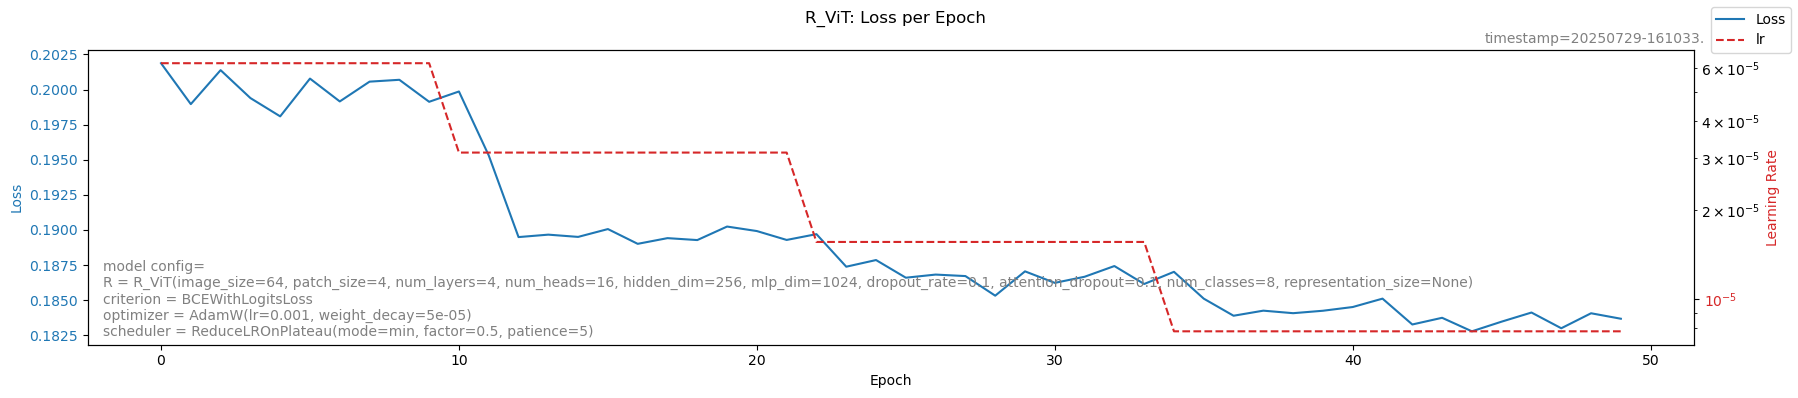

In [ ]:
epochs = 50

R_vit_ref = R_ViT(
    model_name='R_ViT_ref',
    image_size=64,
    patch_size=4,

    num_layers=4,
    num_heads=16,
    hidden_dim=256,
    mlp_dim=1024,         # 通常為 (hidden_dim * 4) 
    
    dropout=0.1,        
    attention_dropout=0.1,   
    num_classes=8, 
    # representation_size=8 ** 2  # 如果有輸入參數, 則會在最後一層加上一層 linear 層. 否則 `heads_layers["head"] = nn.Linear(hidden_dim, num_classes)`
)

R_vit_ref = R_vit_ref.to(device)
criterion_vit = nn.BCEWithLogitsLoss().to(device)
optimizer_vit = torch.optim.AdamW(R_vit_ref.parameters(), lr=1e-3, weight_decay=5e-5)
scheduler_vit = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer_vit, mode='min', factor=0.5, patience=5)

model_config = f'\
R = {type(R_vit_ref).__name__}({R_vit_ref.model_config}) \n\
criterion = {type(criterion_vit).__name__} \n\
optimizer = {type(optimizer_vit).__name__}(lr={optimizer_vit.defaults['lr']}, weight_decay={optimizer_vit.defaults['weight_decay']}) \n\
scheduler = {type(scheduler_vit).__name__}(mode={scheduler_vit.mode}, factor={scheduler_vit.factor}, patience={scheduler_vit.patience})'
print(model_config)

log_loss, log_lr = train_R(R_vit_ref, train_loader_single_defect, criterion_vit, optimizer_vit, scheduler_vit, epochs=epochs)
fig, timestamp = draw_loss_with_lr(type(R_vit_ref).__name__, log_loss, log_lr, epochs=epochs, model_config=model_config)

# 51m 42.9s
# R = MyViT(image_size=64, patch_size=4, num_layers=4, num_heads=8, hidden_dim=256, mlp_dim=1024, dropout_rate=0.1, attention_dropout=0.1, num_classes=8, representation_size=None) 
# criterion = BCEWithLogitsLoss 
# optimizer = AdamW(lr=0.001, weight_decay=0.0001) 
# scheduler = ReduceLROnPlateau(mode=min, factor=0.5, patience=5)
# Epoch [ 10/200] loss: 0.2836319948777114019, lr: 0.001000000
# Epoch [ 20/200] loss: 0.2882055064829269209, lr: 0.001000000
# Epoch [ 30/200] loss: 0.2819972454321266198, lr: 0.001000000
# Epoch [ 40/200] loss: 0.2816676858923222726, lr: 0.001000000
# Epoch [ 50/200] loss: 0.2781335639186424680, lr: 0.000500000
# Epoch [ 60/200] loss: 0.2797857297234015994, lr: 0.000500000
# Epoch [ 70/200] loss: 0.2749065613687628473, lr: 0.000250000
# Epoch [ 80/200] loss: 0.2734470671356314386, lr: 0.000125000
# Epoch [ 90/200] loss: 0.2701399344028813099, lr: 0.000125000
# Epoch [100/200] loss: 0.2674003274428962684, lr: 0.000062500
# Epoch [110/200] loss: 0.2488340298728187461, lr: 0.000062500
# Epoch [120/200] loss: 0.2292508943246142628, lr: 0.000062500
# Epoch [130/200] loss: 0.2217969907687442066, lr: 0.000062500
# Epoch [140/200] loss: 0.2135269149105147590, lr: 0.000015625
# Epoch [150/200] loss: 0.2052345632916629803, lr: 0.000007813
# Epoch [160/200] loss: 0.2040549606674968708, lr: 0.000003906
# Epoch [170/200] loss: 0.2035678874443073161, lr: 0.000001953
# Epoch [180/200] loss: 0.2033046181544218844, lr: 0.000001953
# Epoch [190/200] loss: 0.2034778472515616221, lr: 0.000001953
# Epoch [200/200] loss: 0.2026491762682943176, lr: 0.000000977

# 67m 57.7s
# R = R_ViT(image_size=64, patch_size=4, num_layers=4, num_heads=16, hidden_dim=256, mlp_dim=1024, dropout_rate=0.1, attention_dropout=0.1, num_classes=8, representation_size=None) 
# criterion = BCEWithLogitsLoss 
# optimizer = AdamW(lr=0.001, weight_decay=5e-05) 
# scheduler = ReduceLROnPlateau(mode=min, factor=0.5, patience=5)
# Epoch [ 10/150] loss: 0.285329032, lr: 0.001000000
# Epoch [ 20/150] loss: 0.283510183, lr: 0.001000000
# Epoch [ 30/150] loss: 0.279924168, lr: 0.000500000
# Epoch [ 40/150] loss: 0.277346650, lr: 0.000250000
# Epoch [ 50/150] loss: 0.276562207, lr: 0.000250000
# Epoch [ 60/150] loss: 0.274855491, lr: 0.000125000
# Epoch [ 70/150] loss: 0.272300650, lr: 0.000125000
# Epoch [ 80/150] loss: 0.268749513, lr: 0.000125000
# Epoch [ 90/150] loss: 0.256402953, lr: 0.000062500
# Epoch [100/150] loss: 0.230523253, lr: 0.000062500
# Epoch [110/150] loss: 0.216138584, lr: 0.000062500
# Epoch [120/150] loss: 0.209288228, lr: 0.000062500
# Epoch [130/150] loss: 0.207541372, lr: 0.000062500
# Epoch [140/150] loss: 0.202240083, lr: 0.000062500
# Epoch [150/150] loss: 0.203249787, lr: 0.000062500
# Epoch [ 10/ 50] loss: 0.199129840, lr: 0.000062500
# Epoch [ 20/ 50] loss: 0.190239757, lr: 0.000031250
# Epoch [ 30/ 50] loss: 0.187047270, lr: 0.000015625
# Epoch [ 40/ 50] loss: 0.184240358, lr: 0.000007813
# Epoch [ 50/ 50] loss: 0.183671367, lr: 0.000007813


# 59m 45.2s
# R = MyViT(image_size=64, patch_size=4, num_layers=4, num_heads=16, hidden_dim=1024, mlp_dim=4096, dropout_rate=0.1, attention_dropout=0.1, num_classes=8, representation_size=None) 
# criterion = BCEWithLogitsLoss 
# optimizer = AdamW(lr=0.001, weight_decay=0.0001) 
# scheduler = ReduceLROnPlateau(mode=min, factor=0.5, patience=5)
# Epoch [ 10/200] loss: 0.291558036, lr: 0.001000000
# Epoch [ 20/200] loss: 0.290608480, lr: 0.000500000
# Epoch [ 30/200] loss: 0.282994510, lr: 0.000500000


# R = R_ViT(image_size=64, patch_size=4, num_layers=4, num_heads=8, hidden_dim=1024, mlp_dim=4096, dropout_rate=0.1, attention_dropout=0.1, num_classes=8, representation_size=None) 
# criterion = BCEWithLogitsLoss 
# optimizer = AdamW(lr=0.001, weight_decay=0.0001) 
# scheduler = ReduceLROnPlateau(mode=min, factor=0.5, patience=5)
# Epoch [ 10/200] loss: 0.293630835, lr: 0.001000000
# Epoch [ 20/200] loss: 1.308749712, lr: 0.000500000
# Epoch [ 30/200] loss: 0.290022987, lr: 0.000250000

# 22m56.0s
# R = R_ViT(image_size=64, patch_size=4, num_layers=4, num_heads=8, hidden_dim=512, mlp_dim=2048, dropout_rate=0.1, attention_dropout=0.1, num_classes=8, representation_size=None) 
# criterion = BCEWithLogitsLoss 
# optimizer = AdamW(lr=0.001, weight_decay=0.0001) 
# scheduler = ReduceLROnPlateau(mode=min, factor=0.5, patience=5)
# Epoch [ 10/ 20] loss: 0.287987127, lr: 0.001000000
# Epoch [ 20/ 20] loss: 0.293393735, lr: 0.001000000
# Epoch [ 10/ 20] loss: 0.283917601, lr: 0.000500000
# Epoch [ 20/ 20] loss: 0.283184834, lr: 0.000250000

# 76m 4.9s
# R = R_ViT(image_size=64, patch_size=4, num_layers=4, num_heads=16, hidden_dim=512, mlp_dim=2048, dropout_rate=0.1, attention_dropout=0.1, num_classes=8, representation_size=None) 
# criterion = BCEWithLogitsLoss 
# optimizer = AdamW(lr=0.001, weight_decay=0.0001) 
# scheduler = ReduceLROnPlateau(mode=min, factor=0.5, patience=5)
# Epoch [ 10/ 20] loss: 0.287181726, lr: 0.001000000
# Epoch [ 20/ 20] loss: 0.279930159, lr: 0.001000000
# Epoch [ 10/130] loss: 0.281266429, lr: 0.000500000
# Epoch [ 20/130] loss: 0.274634148, lr: 0.000250000
# Epoch [ 30/130] loss: 0.272129028, lr: 0.000250000
# Epoch [ 40/130] loss: 0.273692178, lr: 0.000125000
# Epoch [ 50/130] loss: 0.269716253, lr: 0.000062500
# Epoch [ 60/130] loss: 0.267116463, lr: 0.000062500
# Epoch [ 70/130] loss: 0.266535426, lr: 0.000062500
# Epoch [ 80/130] loss: 0.265516666, lr: 0.000031250
# Epoch [ 90/130] loss: 0.265111660, lr: 0.000031250
# Epoch [100/130] loss: 0.263860209, lr: 0.000015625

In [23]:
save_text_loss_of_experiment(timestamp, R_vit_ref.name, model_config, log_loss, log_lr)
save_fig_of_experiment('loss', fig, timestamp, R_vit_ref.name)

G:\我的雲端硬碟\2.Study\Master\Lab\Implementation\20250627-augmentation on MixedWM38\record of experiment 20250729-154815_R_ViT_ref_loss.txt

G:\我的雲端硬碟\2.Study\Master\Lab\Implementation\20250627-augmentation on MixedWM38\record of experiment record of experiment\20250729-154815_R_ViT_ref_loss.png



###### inference

C:\Users\Nicole\AppData\Local\Temp\ipykernel_32700\2911187054.py:41: RuntimeWarning: invalid value encountered in divide
  cm = cm.astype('float') / cm.sum(axis=1, keepdims=True)


AttributeError: 'tuple' object has no attribute 'show'

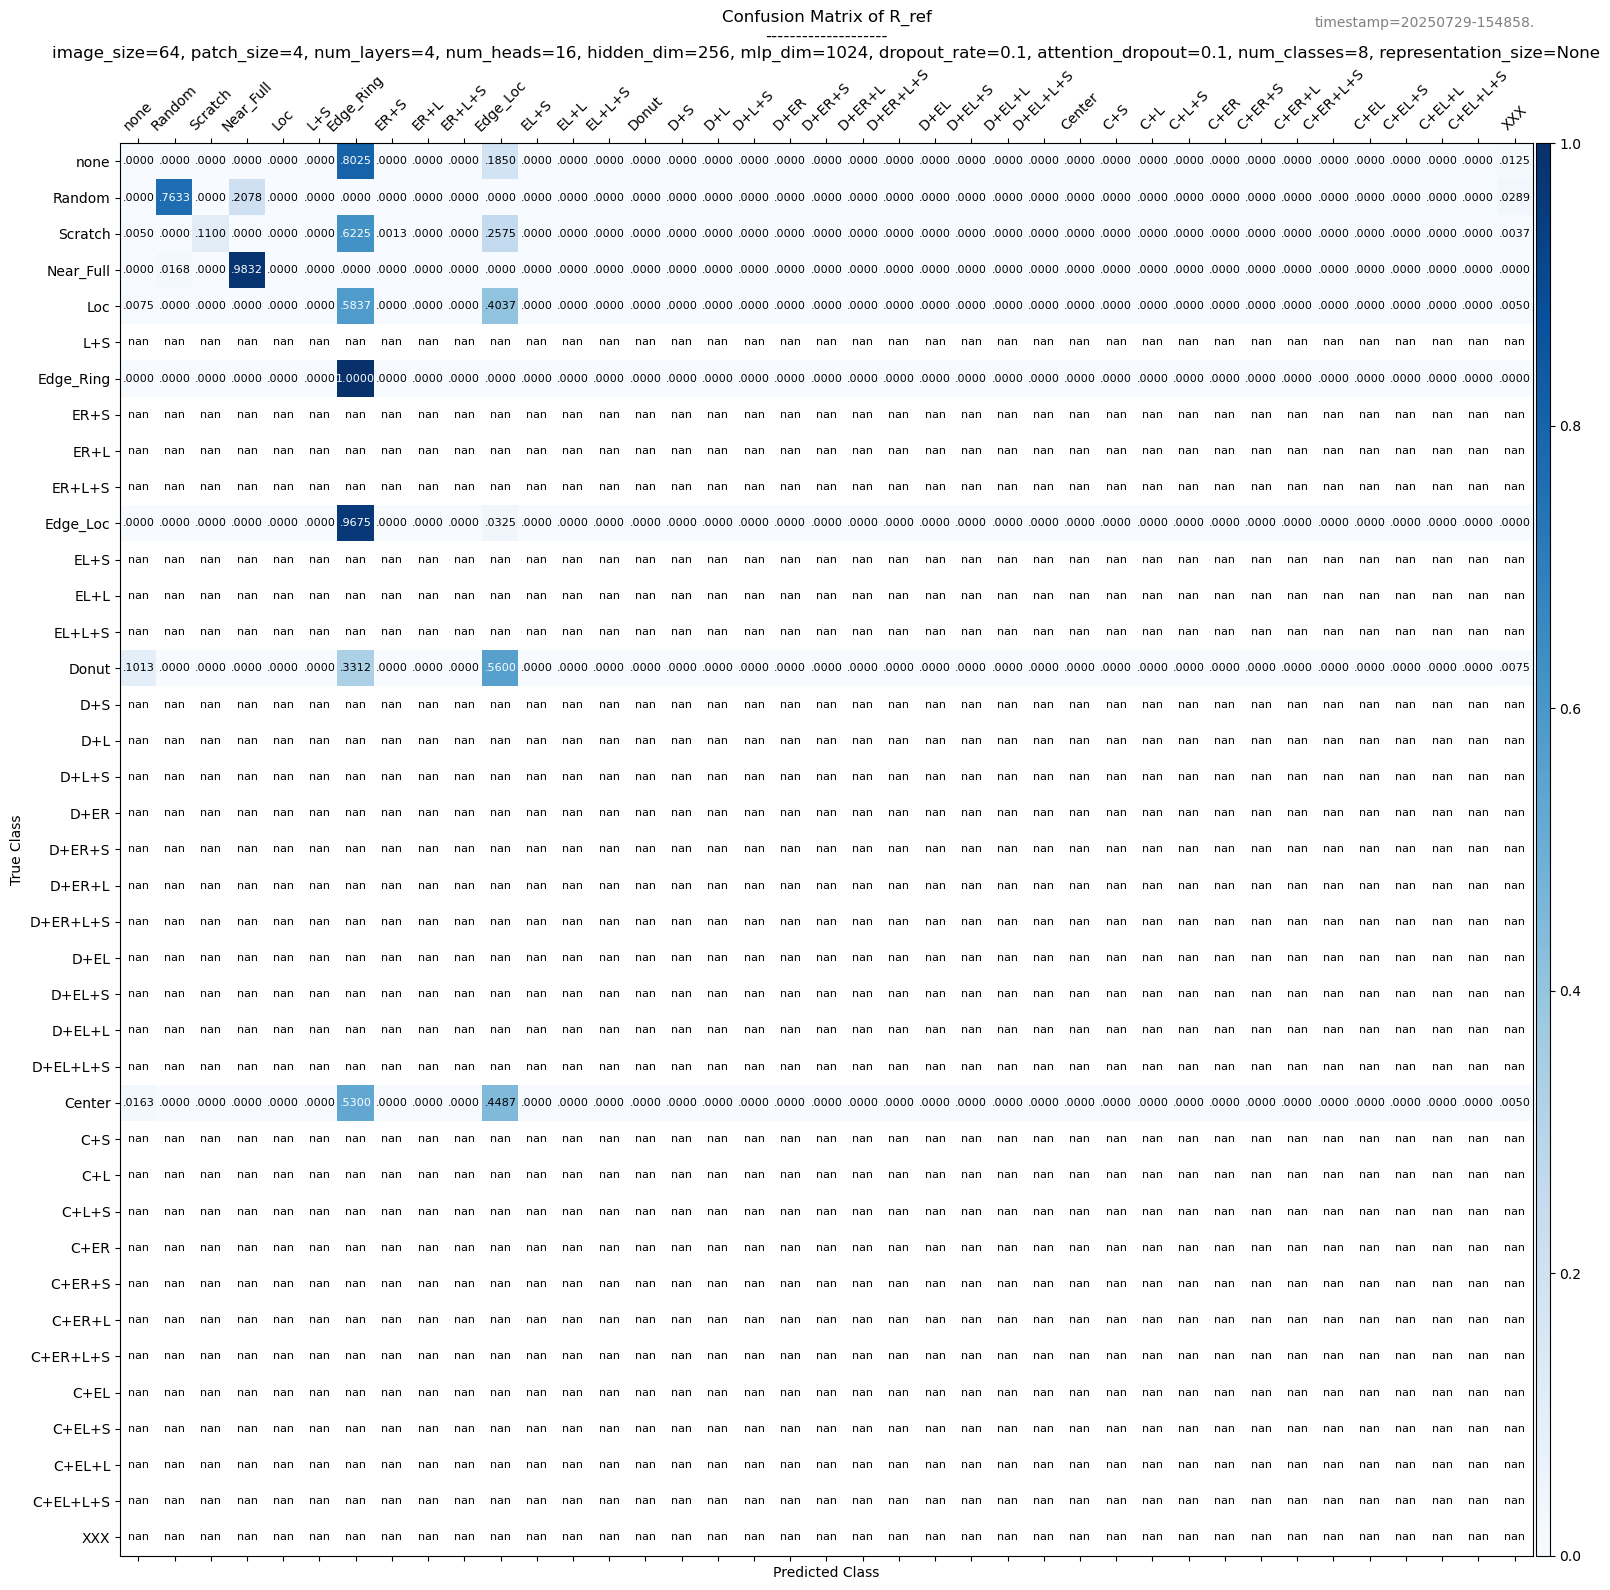

In [ ]:
# fig = inference_Rref(R_vit_ref, test_loader, labels_in_code)
fig, timestamp = inference_Rref(R_vit_ref, train_loader_single_defect, labels_in_code)
fig.show()

In [ ]:
save_fig_of_experiment('cm', fig, timestamp, R_vit_ref.name)

G:\我的雲端硬碟\2.Study\Master\Lab\Implementation\20250627-augmentation on MixedWM38\record of experiment record of experiment\20250729-154858_R_ViT_ref_cm.png



#### A: feature association network


##### Stitching Module

In [ ]:
class FeatureStitchingModule(nn.Module):
    """
    ###### 這部分也需要訓練吧? 那loss要怎麼訂? 用 perception? ######
    拼接 f1, f2, f3, f4, 再轉換成 `(B, out_channels, out_size[0], out_size[1])` 並輸出.

    stitch 後的輸出, 會作為 A 在 forward 的輸入.

    `forward(self, features)`
    - features: tuple of (f1, f2, f3, f4), where each feature map has shape (B, R.n_features//k, H_k, W_k) for k=8, 4, 2, 1.
    """

    def __init__(self, out_channels=64, out_size=(16, 16)):
        super(FeatureStitchingModule, self).__init__()

        # input shape: (B, R.n_features//8, 32, 32)
        self.process_f1 = nn.Sequential(
            nn.Conv2d(8, out_channels, kernel_size=1), 
            nn.AdaptiveMaxPool2d(out_size), 
            nn.ReLU()
        )

        # input shape: (B, R.n_features//4, 16, 16)
        self.process_f2 = nn.Sequential(
            nn.Conv2d(16, out_channels, kernel_size=1), 
            # nn.AdaptiveMaxPool2d(out_size), 
            nn.ReLU()
        )

        # input shape: (B, R.n_features//2, 8, 8)
        self.process_f3 = nn.Sequential(
            nn.Conv2d(32, out_channels, kernel_size=1), 
            nn.Upsample(out_size, mode='nearest'),
            nn.ReLU()
        )

        # input shape: (B, R.n_features, 4, 4)
        self.process_f4 = nn.Sequential(
            nn.Conv2d(64, out_channels, kernel_size=1), 
            nn.Upsample(out_size, mode='nearest'),
            nn.ReLU()
        )

        self.final_conv = nn.Conv2d(out_channels * 4, out_channels, kernel_size=1)

    def forward(self, features):
        f1, f2, f3, f4 = features
        f1 = self.process_f1(f1)
        f2 = self.process_f2(f2)
        f3 = self.process_f3(f3)
        f4 = self.process_f4(f4)

        # concatenate along channel dimension
        stitched_features = torch.cat((f1, f2, f3, f4), dim=1)
        stitched_features = self.final_conv(stitched_features)
        return stitched_features
        # 如果 stitching module 需要訓練, 且使用 f1 計算 loss_perception, 那這裡是不是要改為 `return stitched_features` ?

In [ ]:
# # 這不是文獻中的 FeatureStitchingModule, 是我自己想像的.
# class FeatureStitchingModule(nn.Module):
#     """
#     stitching the gray features and reference features to form a new feature map.
#     input: gray_features(f1g, f2g, f3g, f4g), ref_features(f1r, f2r, f3r, f4r)
#     output: stitched_features(f1, f2, f3, f4). shape=(B, n_features, 8, 8)

#     :param gray_features: tuple of gray features (f1g, f2g, f3g, f4g)
#     :param ref_features: tuple of reference features (f1r, f2r, f3r, f4r)
#     :return: stitched_features: tuple of stitched features (f1, f2, f3, f4)
#     """
#     def __init__(self, out_features=16, out_shape=(8, 8)):
#         super(FeatureStitchingModule, self).__init__()
#         # out_features = 16
#         # out_shape = (8, 8)

#         self.process_f1 = nn.Sequential(
#             # forward 時, 會先把 gray_features 和 ref_features 的 f1 concatenates 起來, 
#             # 才輸入到 process_f1, 所以這裡的 input shape= (B, 2 * n_features // 8, 32, 32)
#             nn.Conv2d(8*2, out_features, kernel_size=1), 
#             nn.AdaptiveMaxPool2d(out_shape),
#             nn.ReLU()
#         )

#         self.process_f2 = nn.Sequential(
#             # forward 時, 會先把 gray_features 和 ref_features 的 f2 concatenates 起來, 
#             # 才輸入到 process_f2, 所以這裡的 input shape= (B, 2 * n_features // 4, 16, 16)
#             nn.Conv2d(16*2, out_features, kernel_size=1), 
#             nn.AdaptiveMaxPool2d(out_shape),
#             nn.ReLU()
#         )

#         self.process_f3 = nn.Sequential(
#             # forward 時, 會先把 gray_features 和 ref_features 的 f3 concatenates 起來, 
#             # 才輸入到 process_f3, 所以這裡的 input shape= (B, 2 * n_features // 2, 8, 8)
#             nn.Conv2d(32*2, out_features, kernel_size=1), 
#             # nn.AdaptiveMaxPool2d(out_shape),
#             nn.ReLU()
#         )

#         self.process_f4 = nn.Sequential(
#             # forward 時, 會先把 gray_features 和 ref_features 的 f4 concatenates 起來, 
#             # 才輸入到 process_f4, 所以這裡的 input shape= (B, 2 * n_features, 4, 4)
#             nn.Conv2d(64*2, out_features, kernel_size=1), 
#             nn.Upsample(out_shape, mode='nearest'),
#             nn.ReLU()
#         )

#         self.final_conv = nn.Sequential(
#             nn.Conv2d(4 * out_features, 64, kernel_size=1),
#             nn.ReLU()
#         )

#     def forward(self, gray_features, ref_features):
#         f1g, f2g, f3g, f4g = gray_features
#         f1r, f2r, f3r, f4r = ref_features

#         # stack gray and ref features
#         f1 = torch.cat((f1g, f1r), dim=1)
#         f2 = torch.cat((f2g, f2r), dim=1)
#         f3 = torch.cat((f3g, f3r), dim=1)
#         f4 = torch.cat((f4g, f4r), dim=1)

#         # process each feature map
#         f1 = self.process_f1(f1)
#         f2 = self.process_f2(f2)
#         f3 = self.process_f3(f3)
#         f4 = self.process_f4(f4)

#         # concatenate all processed features
#         stitched_features = torch.cat((f1, f2, f3, f4), dim=1)

#         # final convolution to reduce channels
#         stitched_features = self.final_conv(stitched_features)

#         return stitched_features




##### A

In [ ]:
class A_FeatureAssociation(nn.Module):
    """
    `forward(self, gray_prime, ref_prime, ref_wafermap)`
    - gray_prime: output of `stitching_module(gray_features)`. shape=`(B, stitch_out_channels, 16, 16)`
    - ref_prime: output of `stitching_module(ref_features)`. shape=`(B, stitch_out_channels, 16, 16)`
    - ref_wafermap: reference wafermap, shape=`(B, 1, 64, 64)`
    """
    def __init__(self, stitch_out_channels=16, qk_channel=4, tau=1.0, epsilon=1e-12):
        super(A_FeatureAssociation, self).__init__()
        
        self.stitch_out_channels = stitch_out_channels
        self.qk_channel = qk_channel
        self.tau = nn.Parameter(torch.tensor(tau).to(device)) # 把 tau 設為可學習的參數
        # self.tau = tau # 把 tau 設為固定的參數
        self.epsilon = epsilon

        # 轉換 stitching 後的特徵, kernel_size通常是 1
        self.theta = nn.Conv2d(stitch_out_channels, qk_channel, kernel_size=1)


    def forward(self, gray_prime, ref_prime, ref_image):
        """
        :param gray_prime: output of `stitching_module(gray_features)`. shape=`(B, stitch_out_channels, 16, 16)` 
        :param ref_prime: output of `stitching_module(ref_features)`. shape=`(B, stitch_out_channels, 16, 16)` 
        :param ref_image: reference wafermap, shape=`(B, 1, 64, 64)`
        :return: attenmap: attention map, shape=`(B, 1, 64, 64)`
        :return: wab: weighted average of reference wafermap, shape=`(B, 1, 64, 64)`
        """
        
        B, C, H, W = gray_prime.shape   # gray_prime 和 ref_prime 的 shape 都是 (B, stitch_out_channels, 16, 16)
        assert (H, W) == (16, 16), f"Expected gray_prime and ref_prime to have shape (B, {self.stitch_out_channels}, 16, 16), but got {gray_prime.shape}"
        C_qk = self.qk_channel

        # calculate phi_gray and phi_ref
        phi_gray = self.theta(gray_prime)
        phi_ref = self.theta(ref_prime)

        phi_gray = phi_gray - phi_gray.mean(dim=1, keepdim=True)  # normalize across channel dimension
        phi_ref = phi_ref - phi_ref.mean(dim=1, keepdim=True)

        phi_gray = F.normalize(phi_gray, p=2, dim=1, eps=self.epsilon)  # `p=2` means L2 normalization
        phi_ref = F.normalize(phi_ref, p=2, dim=1, eps=self.epsilon)

        # calculate f_matrix
        phi_gray_flat = phi_gray.view(B, C_qk, H * W)
        phi_ref_flat = phi_ref.view(B, C_qk, H * W)
        f_matrix = torch.bmm(phi_gray_flat.transpose(1, 2), phi_ref_flat) # output shape=(B, H*W, H*W)
        # ↑ f_matrix 的內容是 "gray 的每個 pixel 與 ref 的每個 pixel 之間的相似度"
        # 如果將計算方式改為 `torch.bmm(phi_gray_flat, phi_ref_flat.transpose(1, 2))`,
        # 則 output shape=(C_qk, C_qk), 代表的意義是 "phi_gray 通道與 phi_ref 通道之間的相似程度", 就不是每個 pixel 之間的相似度了.

        # calculate wab
        # wab 提供了從 ref_wafermap 提取的、經過加權處理的顏色資訊，用於指導 gray 的著色方式
        # wab 相比 attenmap, wab 較側重於顏色資訊本身, 即從 ref_wafermap 中提取並加權後用於色彩化的具體顏色值
        attention_weights = F.softmax(f_matrix / self.tau, dim=2)   # shape=(B, H*W, H*W)  # dim=2 是對參考像素維度進行 softmax. 
        ref_image = F.interpolate(ref_image, size=(H, W), mode='nearest')
        assert ref_image.shape == (B, 1, H, W), f"Expected ref_wafermap to have shape (B, 1, {H}, {W}), but got {ref_image.shape}"
        ref_wafermap_flat = ref_image.view(B, 1, H * W)
        # 根據 attention_weights 對 ref_image 的顏色 (ref_flat) 進行加權求和
        # attention_weights: (B, H*W, H*W)
        # ref_wafermap_flat: (B, 1, H*W). 需要轉置為 (B, H*W_ref, 1)
        wab_flat = torch.bmm(attention_weights, ref_wafermap_flat.transpose(1, 2))  # shape=(B, H*W, 1)
        wab = wab_flat.view(B, 1, H, W)

        # calculate attenmap
        # attenmap 提供關於 gray 和 ref 之間, 語義對應和特徵相似性的資訊
        # attenmap 相比 wab, 更側重於特徵層面的對應關係和相似性, 它表示模型在圖像不同區域之間分配的注意力或重要性, 以此來指導色彩的傳播和對齊
        attenmap_flat, _ = torch.max(attention_weights, dim=2)  # shape=(B, H*W)
        attenmap = attenmap_flat.view(B, 1, H, W)
        # ↑這樣的寫法會得到「每個位置最大注意力的值」，讓某個位置只受單一最重要參考點影響
        # 也可以試試看別的寫法: attention_weights.sum(dim=1) #####
        # 也可以試試看別的寫法: torch.mean(attention_weights, dim=2) #####
        # 這樣的寫法能確保對每個目標位置的注意力權重總和被保留，得到的值是「對所有參考位置的整體注意力量」
        
        return attenmap, wab

#### F class

In [ ]:
class F_feature_processing(nn.Module):

    def __init__(self, R_gray, R_ref, stitch_out_channels=16, qk_channel=4, out_size=(16, 16)):
        
        super(F_feature_processing, self).__init__()
        self.stitch_out_channels = stitch_out_channels
        self.qk_channel = qk_channel

        self.R_gray = R_gray
        self.R_ref = R_ref
        self.stitcher = FeatureStitchingModule(out_channels=stitch_out_channels, out_size=out_size).to(device)
        self.A = A_FeatureAssociation(stitch_out_channels=stitch_out_channels, qk_channel=qk_channel).to(device)

    def forward(self, gray_image, ref_image):
        _, gray_features = self.R_gray(gray_image)  # shape=(B, R.n_features, 4, 4)
        _, ref_features = self.R_ref(ref_image) # shape=(B, R.n_features, 4, 4)
        
        gray_prime = self.stitcher(gray_features)   # shape=(B, self.stitch_out_channels, 16, 16)
        ref_prime = self.stitcher(ref_features) # shape=(B, self.stitch_out_channels, 16, 16)

        wab, attenmap = self.A(gray_prime, ref_prime, ref_image)

        return wab, attenmap
        